# TCS Internship Project: End-to-End Logistics Data Analytics
## GlobeTrack Logistics Ltd. - Real-Time Fleet Intelligence System

### Project Objective
Build a production-grade analytics system to optimize logistics operations through data-driven insights on:
- Driver performance and safety
- Fleet utilization and maintenance
- Route profitability and efficiency
- Fuel consumption patterns
- Delivery service quality

---

## 1. IMPORT LIBRARIES AND SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. LOAD ALL DATASETS

In [2]:
# Define data path
data_path = 'e:/All-Prog/Data-Visualization/TCS Interhsip - (Project)/'

# Load all CSV files
drivers = pd.read_csv(data_path + 'drivers.csv')
trucks = pd.read_csv(data_path + 'trucks.csv')
trailers = pd.read_csv(data_path + 'trailers.csv')
routes = pd.read_csv(data_path + 'routes.csv')
loads = pd.read_csv(data_path + 'loads.csv')
trips = pd.read_csv(data_path + 'trips.csv')
customers = pd.read_csv(data_path + 'customers.csv')
facilities = pd.read_csv(data_path + 'facilities.csv')
fuel_purchases = pd.read_csv(data_path + 'fuel_purchases.csv')
maintenance = pd.read_csv(data_path + 'maintenance_records.csv')
delivery_events = pd.read_csv(data_path + 'delivery_events.csv')
safety_incidents = pd.read_csv(data_path + 'safety_incidents.csv')
driver_metrics = pd.read_csv(data_path + 'driver_monthly_metrics.csv')
truck_metrics = pd.read_csv(data_path + 'truck_utilization_metrics.csv')

print('All datasets loaded successfully!')
print(f'\nDataset Sizes:')
print(f'Drivers: {len(drivers)} records')
print(f'Trucks: {len(trucks)} records')
print(f'Trips: {len(trips)} records')
print(f'Loads: {len(loads)} records')
print(f'Delivery Events: {len(delivery_events)} records')
print(f'Fuel Purchases: {len(fuel_purchases)} records')
print(f'Maintenance Records: {len(maintenance)} records')
print(f'Safety Incidents: {len(safety_incidents)} records')

All datasets loaded successfully!

Dataset Sizes:
Drivers: 150 records
Trucks: 120 records
Trips: 85410 records
Loads: 85410 records
Delivery Events: 170820 records
Fuel Purchases: 196442 records
Maintenance Records: 2920 records
Safety Incidents: 170 records


## 3. EXPLORATORY DATA ANALYSIS (EDA)

### 3.1 Data Overview and Structure

In [3]:
# Display basic info for key datasets
print('=== DRIVERS DATASET ===')
print(drivers.head())
print(f'\nShape: {drivers.shape}')
print(f'Missing values:\n{drivers.isnull().sum()}')
print(f'\nData types:\n{drivers.dtypes}')

=== DRIVERS DATASET ===
  driver_id first_name  last_name   hire_date termination_date license_number  \
0  DRV00001   Jennifer  Hernandez  2014-10-31              NaN    DL673510887   
1  DRV00002    William     Martin  2020-10-02              NaN    DL128955006   
2  DRV00003    Charles  Hernandez  2021-09-21              NaN    DL523076025   
3  DRV00004    Barbara      Brown  2013-09-08              NaN    DL735540030   
4  DRV00005       Mary   Martinez  2018-12-02              NaN    DL706011277   

  license_state date_of_birth   home_terminal employment_status cdl_class  \
0            WA    1973-11-07          Denver            Active         A   
1            GA    1976-11-03        Columbus            Active         A   
2            NC    1970-04-06  Salt Lake City            Active         A   
3            WA    1995-02-06          Denver            Active         A   
4            AZ    1960-07-15         Chicago            Active         A   

   years_experience  
0   

In [4]:
print('=== TRIPS DATASET ===')
print(trips.head())
print(f'\nShape: {trips.shape}')
print(f'Missing values:\n{trips.isnull().sum()}')
print(f'\nStatistical Summary:')
print(trips[['actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used', 'average_mpg', 'idle_time_hours']].describe())

=== TRIPS DATASET ===
        trip_id       load_id driver_id  truck_id trailer_id dispatch_date  \
0  TRIP00000001  LOAD00000001  DRV00117  TRK00035   TRL00167    2022-01-01   
1  TRIP00000002  LOAD00000002  DRV00141  TRK00108   TRL00082    2022-01-01   
2  TRIP00000003  LOAD00000003  DRV00032  TRK00031   TRL00138    2022-01-01   
3  TRIP00000004  LOAD00000004  DRV00083  TRK00105   TRL00018    2022-01-01   
4  TRIP00000005  LOAD00000005  DRV00044  TRK00076   TRL00054    2022-01-01   

   actual_distance_miles  actual_duration_hours  fuel_gallons_used  \
0                   1314                   26.2              183.8   
1                    515                    8.6               93.6   
2                   2509                   45.0              339.1   
3                    717                   11.1              110.3   
4                   2243                   35.0              328.9   

   average_mpg  idle_time_hours trip_status  
0         7.15              3.5   Complete

In [5]:
print('=== LOADS DATASET ===')
print(loads.head())
print(f'\nShape: {loads.shape}')
print(f'Missing values:\n{loads.isnull().sum()}')

=== LOADS DATASET ===
        load_id customer_id  route_id   load_date     load_type  weight_lbs  \
0  LOAD00000001   CUST00183  RTE00019  2022-01-01       Dry Van       19178   
1  LOAD00000002   CUST00076  RTE00058  2022-01-01       Dry Van       27761   
2  LOAD00000003   CUST00027  RTE00048  2022-01-01  Refrigerated       35594   
3  LOAD00000004   CUST00088  RTE00013  2022-01-01  Refrigerated       33274   
4  LOAD00000005   CUST00185  RTE00020  2022-01-01       Dry Van       40257   

   pieces  revenue  fuel_surcharge  accessorial_charges load_status  \
0      13  3045.23          406.72                  100   Completed   
1      22  1224.48           98.61                    0   Completed   
2      16  7171.12          792.88                    0   Completed   
3      10  1308.20          141.33                   50   Completed   
4      10  3317.18          738.48                    0   Completed   

  booking_type  
0         Spot  
1    Dedicated  
2         Spot  
3       

### 3.2 Data Type Conversion and Preparation

In [6]:
# Convert date columns to datetime
drivers['hire_date'] = pd.to_datetime(drivers['hire_date'], errors='coerce')
drivers['date_of_birth'] = pd.to_datetime(drivers['date_of_birth'], errors='coerce')
drivers['termination_date'] = pd.to_datetime(drivers['termination_date'], errors='coerce')

trucks['acquisition_date'] = pd.to_datetime(trucks['acquisition_date'], errors='coerce')

trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'], errors='coerce')

# Loads has 'load_date' instead of booking_date (no scheduled_pickup/delivery in loads)
loads['load_date'] = pd.to_datetime(loads['load_date'], errors='coerce')

fuel_purchases['purchase_date'] = pd.to_datetime(fuel_purchases['purchase_date'], errors='coerce')

maintenance['maintenance_date'] = pd.to_datetime(maintenance['maintenance_date'], errors='coerce')

# Delivery events use scheduled_datetime and actual_datetime
delivery_events['scheduled_datetime'] = pd.to_datetime(delivery_events['scheduled_datetime'], errors='coerce')
delivery_events['actual_datetime'] = pd.to_datetime(delivery_events['actual_datetime'], errors='coerce')

# Routes has contract dates
customers['contract_start_date'] = pd.to_datetime(customers['contract_start_date'], errors='coerce')

print('Date columns converted successfully!')

Date columns converted successfully!


## 4. DATA INTEGRATION AND MERGING

In [7]:
# Create comprehensive trip performance dataset
trip_analysis = trips.copy()

# Merge with driver information
trip_analysis = trip_analysis.merge(drivers[['driver_id', 'first_name', 'last_name', 'cdl_class', 'years_experience']], 
                                     on='driver_id', how='left')

# Merge with truck information
trip_analysis = trip_analysis.merge(trucks[['truck_id', 'make', 'model_year', 'fuel_type', 'status']], 
                                     on='truck_id', how='left')

# Merge with load information
trip_analysis = trip_analysis.merge(loads[['load_id', 'customer_id', 'route_id', 'revenue', 'booking_type']], 
                                     on='load_id', how='left')

# Merge with route information (use correct column names: origin_city, destination_city, typical_distance_miles)
trip_analysis = trip_analysis.merge(routes[['route_id', 'origin_city', 'destination_city', 'typical_distance_miles']], 
                                     on='route_id', how='left')

# Merge with customer information
trip_analysis = trip_analysis.merge(customers[['customer_id', 'customer_name', 'customer_type']], 
                                     on='customer_id', how='left')

print(f'Comprehensive trip dataset created: {trip_analysis.shape}')
print(trip_analysis.head())

Comprehensive trip dataset created: (85410, 29)
        trip_id       load_id driver_id  truck_id trailer_id dispatch_date  \
0  TRIP00000001  LOAD00000001  DRV00117  TRK00035   TRL00167    2022-01-01   
1  TRIP00000002  LOAD00000002  DRV00141  TRK00108   TRL00082    2022-01-01   
2  TRIP00000003  LOAD00000003  DRV00032  TRK00031   TRL00138    2022-01-01   
3  TRIP00000004  LOAD00000004  DRV00083  TRK00105   TRL00018    2022-01-01   
4  TRIP00000005  LOAD00000005  DRV00044  TRK00076   TRL00054    2022-01-01   

   actual_distance_miles  actual_duration_hours  fuel_gallons_used  \
0                   1314                   26.2              183.8   
1                    515                    8.6               93.6   
2                   2509                   45.0              339.1   
3                    717                   11.1              110.3   
4                   2243                   35.0              328.9   

   average_mpg  ...  status customer_id  route_id  revenue boo

## 5. CALCULATE KEY PERFORMANCE INDICATORS (KPIs)

### 5.1 Driver Performance Metrics

In [8]:
# Driver Performance Metrics
driver_performance = trip_analysis.groupby(['driver_id', 'first_name', 'last_name']).agg({
    'trip_id': 'count',  # Number of trips
    'actual_distance_miles': 'sum',  # Total miles
    'fuel_gallons_used': 'sum',  # Total fuel used
    'average_mpg': 'mean',  # Avg MPG
    'actual_duration_hours': 'sum',  # Total hours
    'idle_time_hours': 'sum',  # Total idle time
    'revenue': 'sum'  # Total revenue
}).reset_index()

driver_performance.columns = ['driver_id', 'first_name', 'last_name', 'trips_count', 
                               'total_miles', 'total_fuel', 'avg_mpg', 'total_hours', 'total_idle_hours', 'total_revenue']

# Calculate additional metrics
driver_performance['revenue_per_mile'] = driver_performance['total_revenue'] / driver_performance['total_miles']
driver_performance['fuel_cost_per_mile'] = (driver_performance['total_fuel'] * 3.5) / driver_performance['total_miles']  # Assuming $3.5/gallon
driver_performance['miles_per_hour'] = driver_performance['total_miles'] / driver_performance['total_hours']
driver_performance['idle_percentage'] = (driver_performance['total_idle_hours'] / driver_performance['total_hours']) * 100

# Get on-time delivery rate from delivery events
on_time_rate = delivery_events.groupby('trip_id')['on_time_flag'].mean().reset_index()
on_time_by_driver = on_time_rate.merge(trips[['trip_id', 'driver_id']], on='trip_id').groupby('driver_id')['on_time_flag'].mean().reset_index()
on_time_by_driver.columns = ['driver_id', 'on_time_delivery_rate']

driver_performance = driver_performance.merge(on_time_by_driver, on='driver_id', how='left')

driver_performance = driver_performance.sort_values('total_revenue', ascending=False)

print('=== TOP 10 DRIVERS BY REVENUE ===')
print(driver_performance.head(10)[['first_name', 'last_name', 'trips_count', 'total_revenue', 'avg_mpg', 'on_time_delivery_rate']])
print(f'\nDriver Performance Summary Statistics:')
print(driver_performance[['avg_mpg', 'revenue_per_mile', 'idle_percentage', 'on_time_delivery_rate']].describe())

=== TOP 10 DRIVERS BY REVENUE ===
    first_name last_name  trips_count  total_revenue   avg_mpg  \
41       Linda     Davis          723     2311844.30  6.502379   
88      Joseph     Jones          735     2311327.90  6.518163   
48     Barbara  Gonzalez          729     2305056.60  6.517476   
13      Thomas  Gonzalez          712     2278574.88  6.497978   
16      Robert   Jackson          749     2275654.76  6.467009   
105     Thomas  Gonzalez          702     2272317.62  6.495812   
122      Linda     Jones          721     2269105.67  6.497184   
120    Richard    Garcia          705     2256066.92  6.492014   
69       Linda    Wilson          703     2229521.23  6.514083   
70     William  Anderson          725     2214003.33  6.509241   

     on_time_delivery_rate  
41                0.547718  
88                0.589796  
48                0.548011  
13                0.557584  
16                0.571429  
105               0.540598  
122               0.549931  
120    

### 5.2 Fleet Utilization Metrics

In [9]:
# Fleet Utilization Metrics
fleet_utilization = trip_analysis.groupby(['truck_id', 'make', 'model_year', 'status']).agg({
    'trip_id': 'count',  # Number of trips
    'actual_distance_miles': 'sum',  # Total miles
    'fuel_gallons_used': 'sum',  # Total fuel used
    'average_mpg': 'mean',  # Avg MPG
    'actual_duration_hours': 'sum',  # Total hours
    'revenue': 'sum'  # Total revenue
}).reset_index()

fleet_utilization.columns = ['truck_id', 'make', 'model_year', 'status', 'trips_count', 
                              'total_miles', 'total_fuel', 'avg_mpg', 'total_hours', 'total_revenue']

# Calculate additional metrics
fleet_utilization['revenue_per_truck'] = fleet_utilization['total_revenue']
fleet_utilization['cost_per_mile'] = (fleet_utilization['total_fuel'] * 3.5) / fleet_utilization['total_miles']
fleet_utilization['miles_per_trip'] = fleet_utilization['total_miles'] / fleet_utilization['trips_count']
fleet_utilization['revenue_per_mile'] = fleet_utilization['total_revenue'] / fleet_utilization['total_miles']

fleet_utilization = fleet_utilization.sort_values('total_revenue', ascending=False)

print('=== TOP 10 TRUCKS BY UTILIZATION ===')
print(fleet_utilization.head(10)[['truck_id', 'make', 'trips_count', 'total_miles', 'avg_mpg', 'total_revenue']])
print(f'\nFleet Utilization Summary:')
print(f'Total Trucks: {len(fleet_utilization)}')
print(f'Active Trucks: {len(fleet_utilization[fleet_utilization["status"] == "Active"])}')
print(f'Average Revenue per Truck: ${fleet_utilization["total_revenue"].mean():,.2f}')
print(f'Average Cost per Mile: ${fleet_utilization["cost_per_mile"].mean():.2f}')

=== TOP 10 TRUCKS BY UTILIZATION ===
    truck_id           make  trips_count  total_miles   avg_mpg  total_revenue
32  TRK00044          Volvo          971      1403922  6.499650     3045707.57
82  TRK00107           Mack          930      1389705  6.491989     3022073.78
30  TRK00041  International          965      1404001  6.504466     3017320.99
41  TRK00055      Peterbilt          977      1417530  6.473019     2997124.44
39  TRK00053      Peterbilt          964      1378108  6.475571     2990269.38
12  TRK00015  International          961      1386604  6.503663     2979377.79
19  TRK00025   Freightliner          963      1370297  6.489730     2942525.23
18  TRK00024          Volvo          941      1362333  6.495569     2938674.70
42  TRK00057           Mack          951      1377066  6.543502     2933620.12
25  TRK00035  International          932      1343802  6.497951     2926212.82

Fleet Utilization Summary:
Total Trucks: 92
Active Trucks: 92
Average Revenue per Truck: $2,7

### 5.3 Route Profitability Analysis

In [10]:
# Route Profitability Analysis
# Calculate route costs from maintenance and fuel by route
route_profitability = trip_analysis.groupby(['route_id', 'origin_city', 'destination_city']).agg({
    'trip_id': 'count',  # Number of trips
    'actual_distance_miles': 'sum',  # Total miles
    'fuel_gallons_used': 'sum',  # Total fuel
    'average_mpg': 'mean',  # Avg MPG
    'revenue': 'sum'  # Total revenue
}).reset_index()

route_profitability.columns = ['route_id', 'origin_city', 'destination_city', 'trips_count', 
                                'total_distance', 'total_fuel', 'avg_mpg', 'total_revenue']

# Calculate costs
route_profitability['fuel_cost'] = route_profitability['total_fuel'] * 3.5  # $3.5 per gallon
route_profitability['estimated_operating_cost'] = route_profitability['fuel_cost'] * 1.3  # Add 30% for other costs
route_profitability['profit'] = route_profitability['total_revenue'] - route_profitability['estimated_operating_cost']
route_profitability['profit_margin'] = (route_profitability['profit'] / route_profitability['total_revenue']) * 100
route_profitability['cost_per_mile'] = route_profitability['estimated_operating_cost'] / route_profitability['total_distance']
route_profitability['revenue_per_mile'] = route_profitability['total_revenue'] / route_profitability['total_distance']

route_profitability = route_profitability.sort_values('profit', ascending=False)

print('=== TOP 10 MOST PROFITABLE ROUTES ===')
print(route_profitability.head(10)[['route_id', 'trips_count', 'total_distance', 'total_revenue', 'estimated_operating_cost', 'profit', 'profit_margin']])
print(f'\nRoute Profitability Summary:')
print(f'Total Routes: {len(route_profitability)}')
print(f'Average Profit Margin: {route_profitability["profit_margin"].mean():.2f}%')
print(f'Most Profitable Route: Route {route_profitability.iloc[0]["route_id"]} with ${route_profitability.iloc[0]["profit"]:,.2f} profit')
print(f'Least Profitable Route: Route {route_profitability.iloc[-1]["route_id"]} with ${route_profitability.iloc[-1]["profit"]:,.2f} profit')

=== TOP 10 MOST PROFITABLE ROUTES ===
    route_id  trips_count  total_distance  total_revenue  \
43  RTE00044         1410         3817963     9979091.72   
15  RTE00016         1465         4118647    10069054.22   
11  RTE00012         1507         3706749     9757537.38   
47  RTE00048         1525         3661229     9586536.90   
45  RTE00046         1534         3583020     9501202.04   
28  RTE00029         1467         3964388     9516077.71   
41  RTE00042         1447         3912108     9070885.01   
2   RTE00003         1496         3082778     7621380.80   
29  RTE00030         1445         3195712     7681556.33   
20  RTE00021         1473         3196415     7595328.46   

    estimated_operating_cost       profit  profit_margin  
43               2697050.720  7282041.000      72.972984  
15               2896138.700  7172915.520      71.237232  
11               2617337.905  7140199.475      73.176245  
47               2584100.610  7002436.290      73.044483  
45    

### 5.4 Fuel Efficiency Analysis

In [11]:
# Fuel Efficiency Analysis
fuel_efficiency = trip_analysis.groupby(['truck_id', 'make']).agg({
    'trip_id': 'count',
    'actual_distance_miles': 'sum',
    'fuel_gallons_used': 'sum',
    'average_mpg': 'mean'
}).reset_index()

fuel_efficiency.columns = ['truck_id', 'make', 'trips', 'total_miles', 'total_fuel', 'avg_mpg']

fuel_efficiency['calculated_mpg'] = fuel_efficiency['total_miles'] / fuel_efficiency['total_fuel']
fuel_efficiency['fuel_cost'] = fuel_efficiency['total_fuel'] * 3.5
fuel_efficiency['cost_per_mile'] = fuel_efficiency['fuel_cost'] / fuel_efficiency['total_miles']

fuel_efficiency = fuel_efficiency.sort_values('calculated_mpg', ascending=False)

print('=== TOP 10 MOST FUEL EFFICIENT TRUCKS ===')
print(fuel_efficiency.head(10)[['truck_id', 'make', 'avg_mpg', 'calculated_mpg', 'total_miles', 'fuel_cost', 'cost_per_mile']])
print(f'\nFuel Efficiency Summary:')
print(f'Fleet Average MPG: {fuel_efficiency["calculated_mpg"].mean():.2f}')
print(f'Best MPG: {fuel_efficiency["calculated_mpg"].max():.2f}')
print(f'Worst MPG: {fuel_efficiency["calculated_mpg"].min():.2f}')
print(f'Total Fuel Cost: ${fuel_efficiency["fuel_cost"].sum():,.2f}')

=== TOP 10 MOST FUEL EFFICIENT TRUCKS ===
    truck_id           make   avg_mpg  calculated_mpg  total_miles  fuel_cost  \
42  TRK00057           Mack  6.543502        6.511129      1377066  740229.70   
44  TRK00059           Mack  6.559430        6.496182      1216720  655541.95   
74  TRK00096       Kenworth  6.523041        6.483934      1221247  659223.95   
72  TRK00093      Peterbilt  6.540033        6.483761      1281778  691916.75   
9   TRK00012   Freightliner  6.535761        6.481388      1341215  724266.55   
37  TRK00051           Mack  6.529890        6.476225      1312973  709580.90   
11  TRK00014  International  6.519187        6.475677      1240298  670361.30   
40  TRK00054   Freightliner  6.498763        6.475620      1331076  719431.65   
49  TRK00064       Kenworth  6.524608        6.471507      1296870  701389.15   
31  TRK00043   Freightliner  6.516202        6.470542      1321161  714633.15   

    cost_per_mile  
42       0.537541  
44       0.538778  
74    

### 5.5 Delivery Performance Metrics

In [12]:
# Delivery Performance Metrics
if len(delivery_events) > 0:
    delivery_performance = delivery_events.groupby('trip_id').agg({
        'on_time_flag': 'mean',
        'detention_minutes': 'sum'
    }).reset_index()
    
    delivery_performance = delivery_performance.merge(trips[['trip_id', 'driver_id', 'truck_id']], on='trip_id')
    
    on_time_rate = (delivery_performance['on_time_flag'].sum() / len(delivery_performance)) * 100
    avg_detention = delivery_performance['detention_minutes'].mean()
    
    print(f'=== DELIVERY PERFORMANCE METRICS ===')
    print(f'Overall On-Time Delivery Rate: {on_time_rate:.2f}%')
    print(f'Average Detention Minutes: {avg_detention:.2f}')
    print(f'Total On-Time Deliveries: {delivery_performance["on_time_flag"].sum()}')
    print(f'Total Late Deliveries: {len(delivery_performance) - delivery_performance["on_time_flag"].sum()}')
else:
    print('No delivery events data available')

=== DELIVERY PERFORMANCE METRICS ===
Overall On-Time Delivery Rate: 55.67%
Average Detention Minutes: 183.07
Total On-Time Deliveries: 47547.5
Total Late Deliveries: 37862.5


### 5.6 Safety and Incident Analysis

In [13]:
# Safety and Incident Analysis
print('=== SAFETY INCIDENT ANALYSIS ===')
if len(safety_incidents) > 0:
    print(f'Total Incidents: {len(safety_incidents)}')
    print(f'\nIncidents by Type:')
    print(safety_incidents['incident_type'].value_counts())
    
    # Calculate total damage (vehicle + cargo)
    total_damage = (safety_incidents['vehicle_damage_cost'] + safety_incidents['cargo_damage_cost']).sum()
    avg_damage = (safety_incidents['vehicle_damage_cost'] + safety_incidents['cargo_damage_cost']).mean()
    
    print(f'\nTotal Damage Cost: ${total_damage:,.2f}')
    print(f'Average Damage Cost per Incident: ${avg_damage:,.2f}')
    
    # Incidents by driver
    driver_incidents = safety_incidents.groupby('driver_id').agg({
        'incident_id': 'count',
        'vehicle_damage_cost': 'sum',
        'cargo_damage_cost': 'sum',
        'preventable_flag': 'sum'
    }).reset_index()
    driver_incidents.columns = ['driver_id', 'total_incidents', 'vehicle_damage', 'cargo_damage', 'preventable_incidents']
    driver_incidents['total_damage'] = driver_incidents['vehicle_damage'] + driver_incidents['cargo_damage']
    driver_incidents = driver_incidents.sort_values('total_incidents', ascending=False)
    
    print(f'\nTop 5 Drivers with Most Incidents:')
    print(driver_incidents[['driver_id', 'total_incidents', 'total_damage', 'preventable_incidents']].head())
else:
    print('No safety incidents data available')

=== SAFETY INCIDENT ANALYSIS ===
Total Incidents: 170

Incidents by Type:
incident_type
DOT Violation         39
Accident              35
Equipment Damage      35
Customer Complaint    34
Moving Violation      27
Name: count, dtype: int64

Total Damage Cost: $2,653,171.82
Average Damage Cost per Incident: $15,606.89

Top 5 Drivers with Most Incidents:
   driver_id  total_incidents  total_damage  preventable_incidents
36  DRV00058                7     117581.75                      3
2   DRV00003                6      48700.26                      2
7   DRV00012                3     104901.54                      2
5   DRV00006                3      49239.16                      1
44  DRV00070                3      61179.09                      3


### 5.7 Maintenance Analysis

In [14]:
# Maintenance Analysis
if len(maintenance) > 0:
    maintenance['maintenance_date'] = pd.to_datetime(maintenance['maintenance_date'], errors='coerce')
    
    maintenance_summary = maintenance.groupby('truck_id').agg({
        'maintenance_id': 'count',
        'labor_hours': 'sum',
        'parts_cost': 'sum',
        'total_cost': 'sum',
        'downtime_hours': 'sum'
    }).reset_index()
    maintenance_summary.columns = ['truck_id', 'maintenance_count', 'total_labor_hours', 'total_parts_cost', 'total_maintenance_cost', 'total_downtime_hours']
    maintenance_summary['cost_per_maintenance'] = maintenance_summary['total_parts_cost'] / maintenance_summary['maintenance_count']
    maintenance_summary = maintenance_summary.sort_values('maintenance_count', ascending=False)
    
    print('=== MAINTENANCE ANALYSIS ===')
    print(f'Total Maintenance Records: {len(maintenance)}')
    print(f'Total Labor Hours: {maintenance["labor_hours"].sum():,.0f}')
    print(f'Total Parts Cost: ${maintenance["parts_cost"].sum():,.2f}')
    print(f'Total Maintenance Cost: ${maintenance["total_cost"].sum():,.2f}')
    print(f'\nTop 10 Trucks Requiring Most Maintenance:')
    print(maintenance_summary.head(10))
else:
    print('No maintenance data available')

=== MAINTENANCE ANALYSIS ===
Total Maintenance Records: 2920
Total Labor Hours: 12,201
Total Parts Cost: $4,450,066.19
Total Maintenance Cost: $5,730,573.28

Top 10 Trucks Requiring Most Maintenance:
     truck_id  maintenance_count  total_labor_hours  total_parts_cost  \
2    TRK00003                 41              176.2          71573.48   
72   TRK00073                 39              153.2          60460.46   
43   TRK00044                 38              167.9          51821.95   
117  TRK00118                 35              154.2          55190.24   
12   TRK00013                 34              137.2          43500.10   
98   TRK00099                 34              143.0          58017.72   
13   TRK00014                 34              169.9          53346.77   
4    TRK00005                 33              153.8          49682.45   
80   TRK00081                 32              142.1          59035.73   
25   TRK00026                 32              142.8          56350.42 

## 6. VISUALIZATIONS

### 6.1 Driver Performance Visualizations

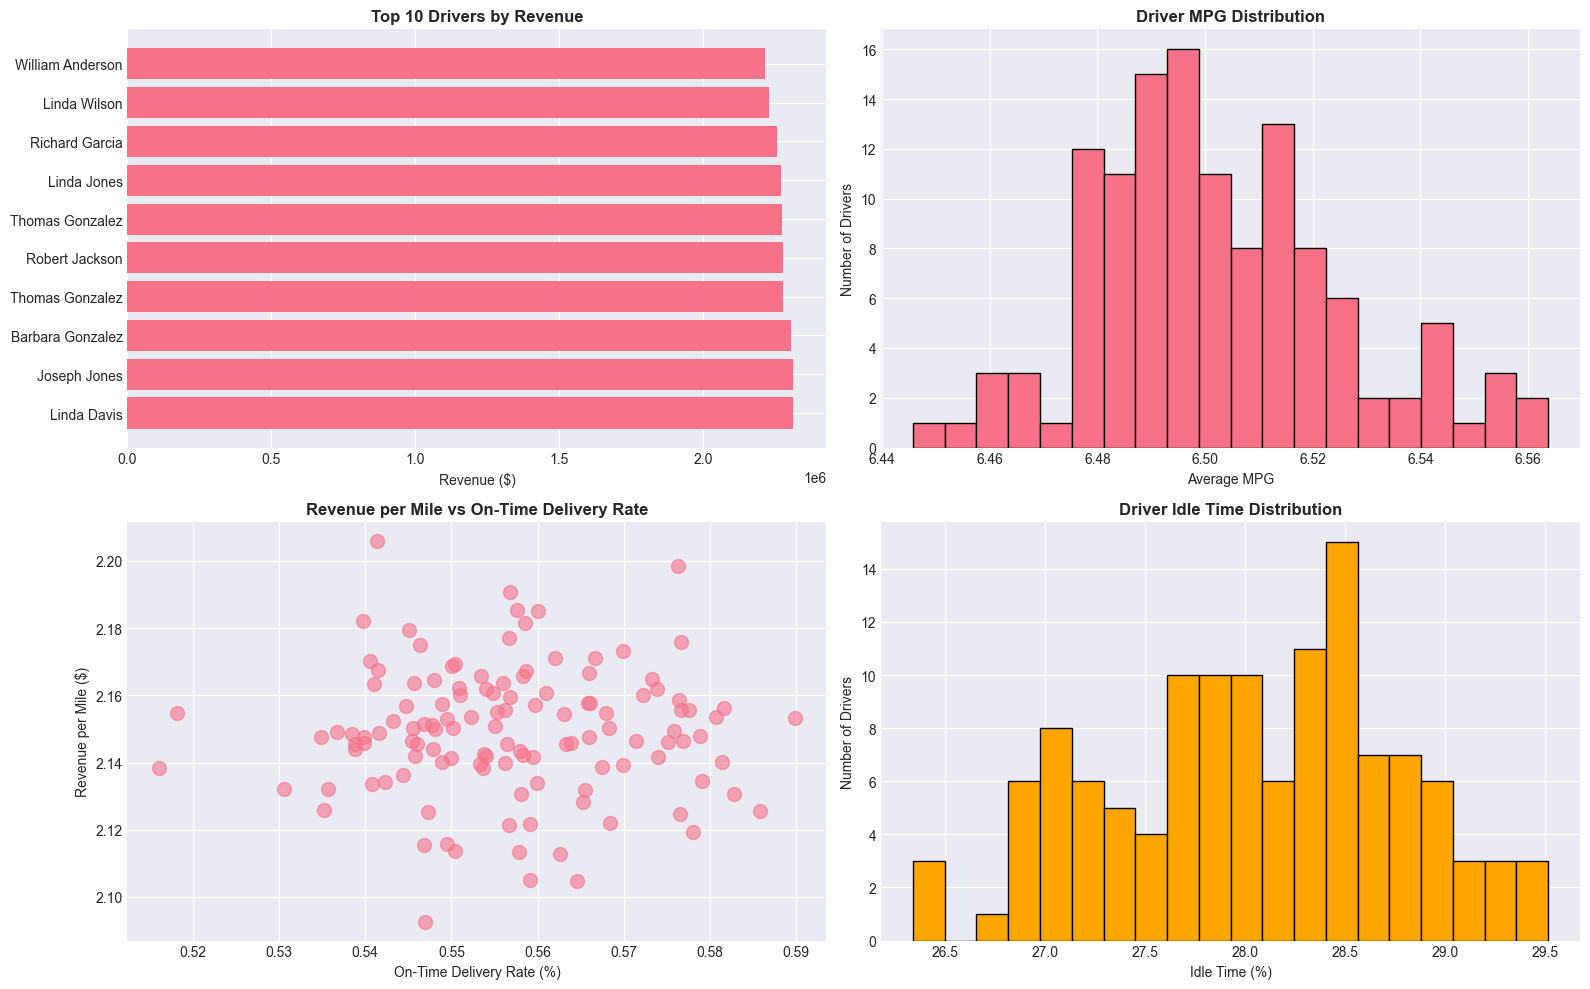

Driver Performance Visualization saved!


In [15]:
# Create driver performance visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top drivers by revenue
top_drivers = driver_performance.head(10)
axes[0, 0].barh(range(len(top_drivers)), top_drivers['total_revenue'])
axes[0, 0].set_yticks(range(len(top_drivers)))
axes[0, 0].set_yticklabels([f"{row['first_name']} {row['last_name']}" for _, row in top_drivers.iterrows()])
axes[0, 0].set_title('Top 10 Drivers by Revenue', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Revenue ($)')

# Average MPG distribution
axes[0, 1].hist(driver_performance['avg_mpg'], bins=20, edgecolor='black')
axes[0, 1].set_title('Driver MPG Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Average MPG')
axes[0, 1].set_ylabel('Number of Drivers')

# Revenue per mile vs On-time delivery rate
axes[1, 0].scatter(driver_performance['on_time_delivery_rate'].fillna(0), 
                    driver_performance['revenue_per_mile'], alpha=0.6, s=100)
axes[1, 0].set_title('Revenue per Mile vs On-Time Delivery Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('On-Time Delivery Rate (%)')
axes[1, 0].set_ylabel('Revenue per Mile ($)')

# Idle time percentage
axes[1, 1].hist(driver_performance['idle_percentage'], bins=20, edgecolor='black', color='orange')
axes[1, 1].set_title('Driver Idle Time Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Idle Time (%)')
axes[1, 1].set_ylabel('Number of Drivers')

plt.tight_layout()
plt.savefig('Driver_Performance_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Driver Performance Visualization saved!')

### 6.2 Fleet Utilization Visualizations

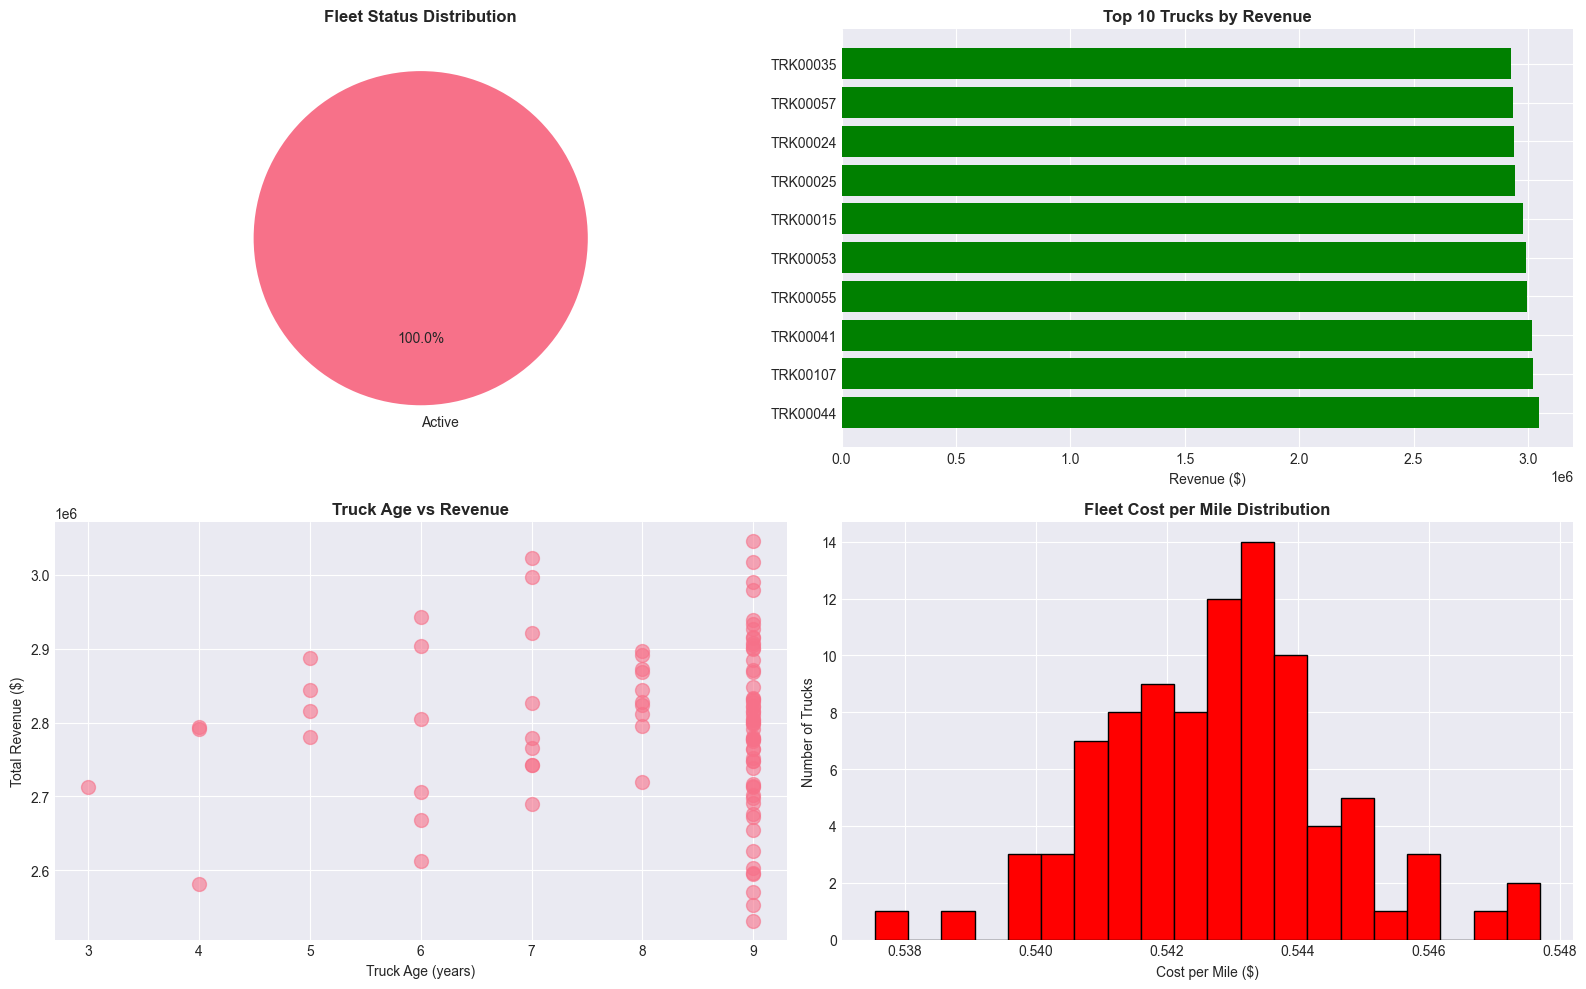

Fleet Utilization Visualization saved!


In [16]:
# Fleet Utilization Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Truck status distribution
status_counts = fleet_utilization['status'].value_counts()
axes[0, 0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Fleet Status Distribution', fontsize=12, fontweight='bold')

# Top trucks by revenue
top_trucks = fleet_utilization.head(10)
axes[0, 1].barh(range(len(top_trucks)), top_trucks['total_revenue'], color='green')
axes[0, 1].set_yticks(range(len(top_trucks)))
axes[0, 1].set_yticklabels(top_trucks['truck_id'])
axes[0, 1].set_title('Top 10 Trucks by Revenue', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Revenue ($)')

# Truck age vs revenue
truck_with_age = fleet_utilization.copy()
truck_with_age['truck_age'] = 2024 - truck_with_age['model_year']
axes[1, 0].scatter(truck_with_age['truck_age'], truck_with_age['total_revenue'], alpha=0.6, s=100)
axes[1, 0].set_title('Truck Age vs Revenue', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Truck Age (years)')
axes[1, 0].set_ylabel('Total Revenue ($)')

# Cost per mile distribution
axes[1, 1].hist(fleet_utilization['cost_per_mile'], bins=20, edgecolor='black', color='red')
axes[1, 1].set_title('Fleet Cost per Mile Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cost per Mile ($)')
axes[1, 1].set_ylabel('Number of Trucks')

plt.tight_layout()
plt.savefig('Fleet_Utilization_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Fleet Utilization Visualization saved!')

### 6.3 Route Profitability Visualizations

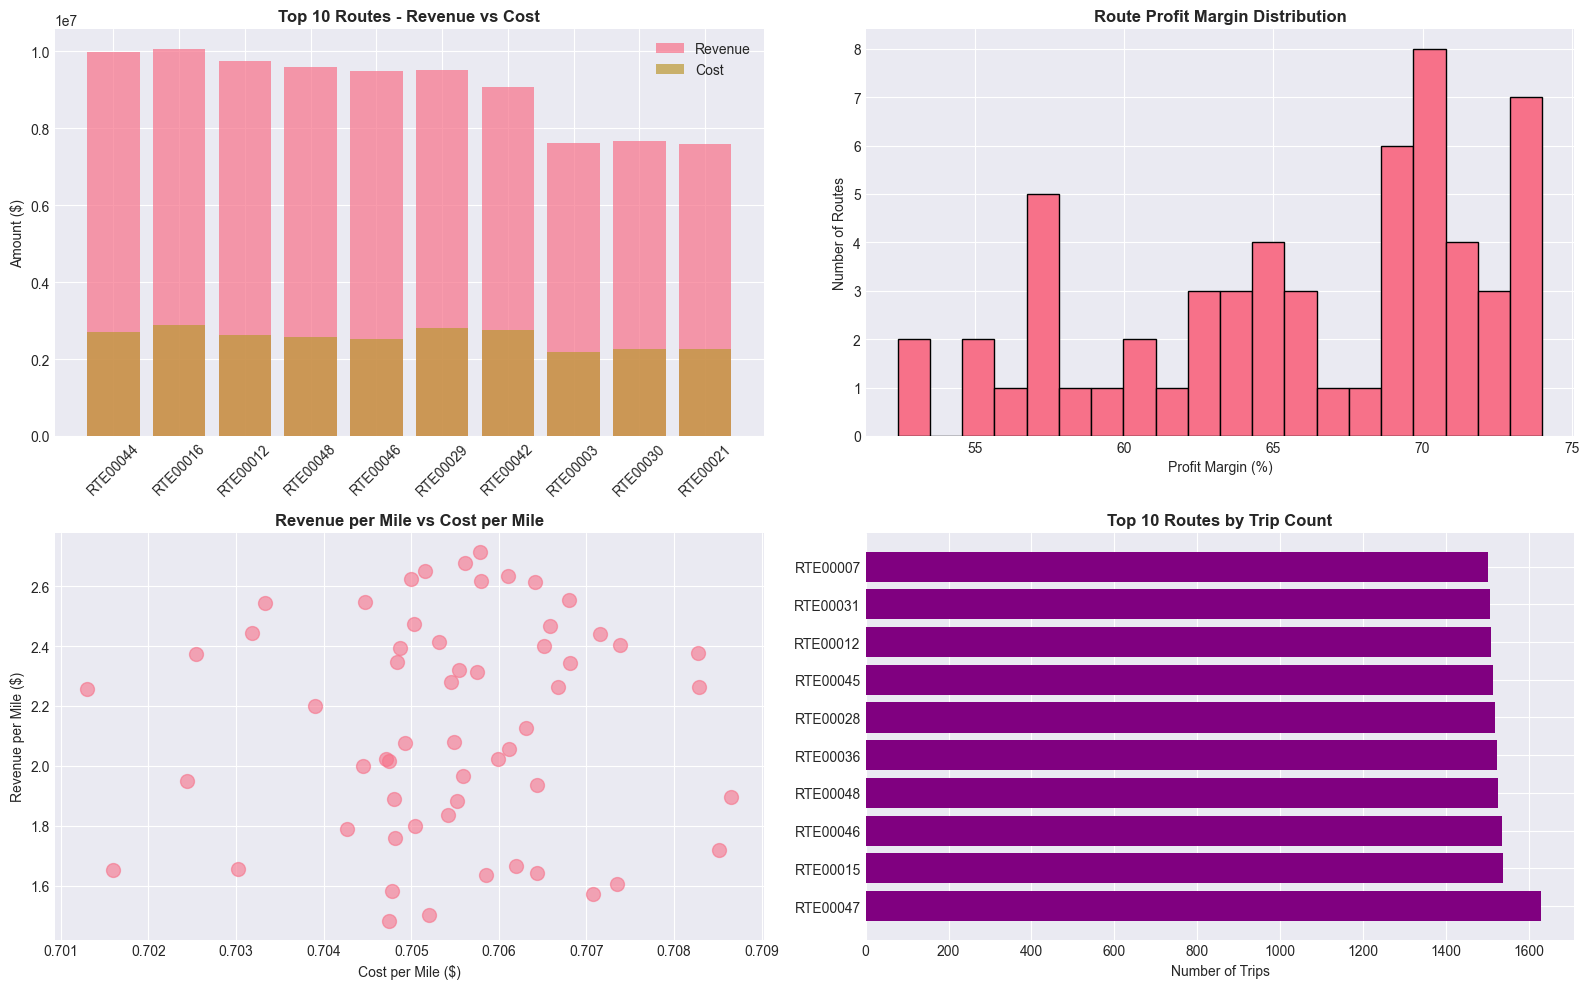

Route Profitability Visualization saved!


In [17]:
# Route Profitability Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top profitable routes
top_routes = route_profitability.head(10)
x_pos = range(len(top_routes))
axes[0, 0].bar(x_pos, top_routes['total_revenue'], label='Revenue', alpha=0.7)
axes[0, 0].bar(x_pos, top_routes['estimated_operating_cost'], label='Cost', alpha=0.7)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(top_routes['route_id'], rotation=45)
axes[0, 0].set_title('Top 10 Routes - Revenue vs Cost', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Amount ($)')
axes[0, 0].legend()

# Profit margin distribution
axes[0, 1].hist(route_profitability['profit_margin'], bins=20, edgecolor='black')
axes[0, 1].set_title('Route Profit Margin Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Profit Margin (%)')
axes[0, 1].set_ylabel('Number of Routes')

# Revenue per mile vs Cost per mile
axes[1, 0].scatter(route_profitability['cost_per_mile'], route_profitability['revenue_per_mile'], alpha=0.6, s=100)
axes[1, 0].set_title('Revenue per Mile vs Cost per Mile', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cost per Mile ($)')
axes[1, 0].set_ylabel('Revenue per Mile ($)')

# Trip count by route
top_route_trips = route_profitability.nlargest(10, 'trips_count')
axes[1, 1].barh(range(len(top_route_trips)), top_route_trips['trips_count'], color='purple')
axes[1, 1].set_yticks(range(len(top_route_trips)))
axes[1, 1].set_yticklabels(top_route_trips['route_id'])
axes[1, 1].set_title('Top 10 Routes by Trip Count', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Trips')

plt.tight_layout()
plt.savefig('Route_Profitability_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Route Profitability Visualization saved!')

### 6.4 Fuel Efficiency Visualizations

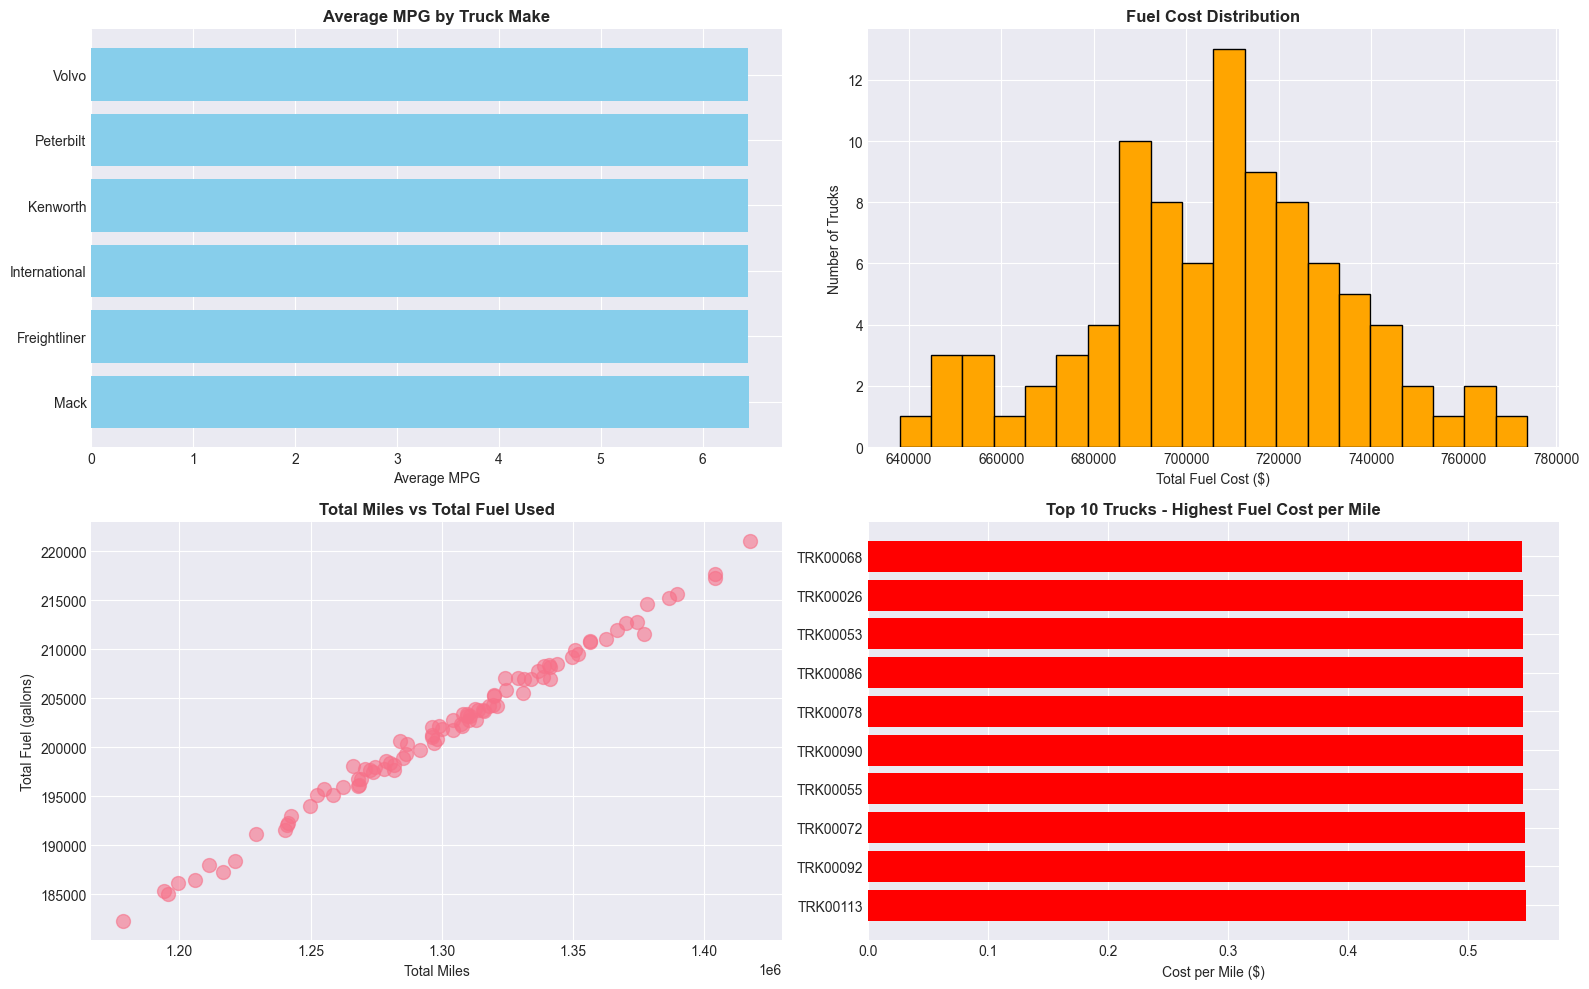

Fuel Efficiency Visualization saved!


In [18]:
# Fuel Efficiency Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# MPG distribution by truck make
fuel_efficiency_make = fuel_efficiency.groupby('make')['calculated_mpg'].agg(['mean', 'count']).reset_index()
fuel_efficiency_make = fuel_efficiency_make.sort_values('mean', ascending=False).head(10)
axes[0, 0].barh(range(len(fuel_efficiency_make)), fuel_efficiency_make['mean'], color='skyblue')
axes[0, 0].set_yticks(range(len(fuel_efficiency_make)))
axes[0, 0].set_yticklabels(fuel_efficiency_make['make'])
axes[0, 0].set_title('Average MPG by Truck Make', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Average MPG')

# Fuel cost distribution
axes[0, 1].hist(fuel_efficiency['fuel_cost'], bins=20, edgecolor='black', color='orange')
axes[0, 1].set_title('Fuel Cost Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Fuel Cost ($)')
axes[0, 1].set_ylabel('Number of Trucks')

# Total miles vs total fuel
axes[1, 0].scatter(fuel_efficiency['total_miles'], fuel_efficiency['total_fuel'], alpha=0.6, s=100)
axes[1, 0].set_title('Total Miles vs Total Fuel Used', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Miles')
axes[1, 0].set_ylabel('Total Fuel (gallons)')

# Cost per mile by truck
top_cost_trucks = fuel_efficiency.nlargest(10, 'cost_per_mile')
axes[1, 1].barh(range(len(top_cost_trucks)), top_cost_trucks['cost_per_mile'], color='red')
axes[1, 1].set_yticks(range(len(top_cost_trucks)))
axes[1, 1].set_yticklabels(top_cost_trucks['truck_id'])
axes[1, 1].set_title('Top 10 Trucks - Highest Fuel Cost per Mile', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cost per Mile ($)')

plt.tight_layout()
plt.savefig('Fuel_Efficiency_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Fuel Efficiency Visualization saved!')

### 6.5 Safety and Maintenance Visualizations

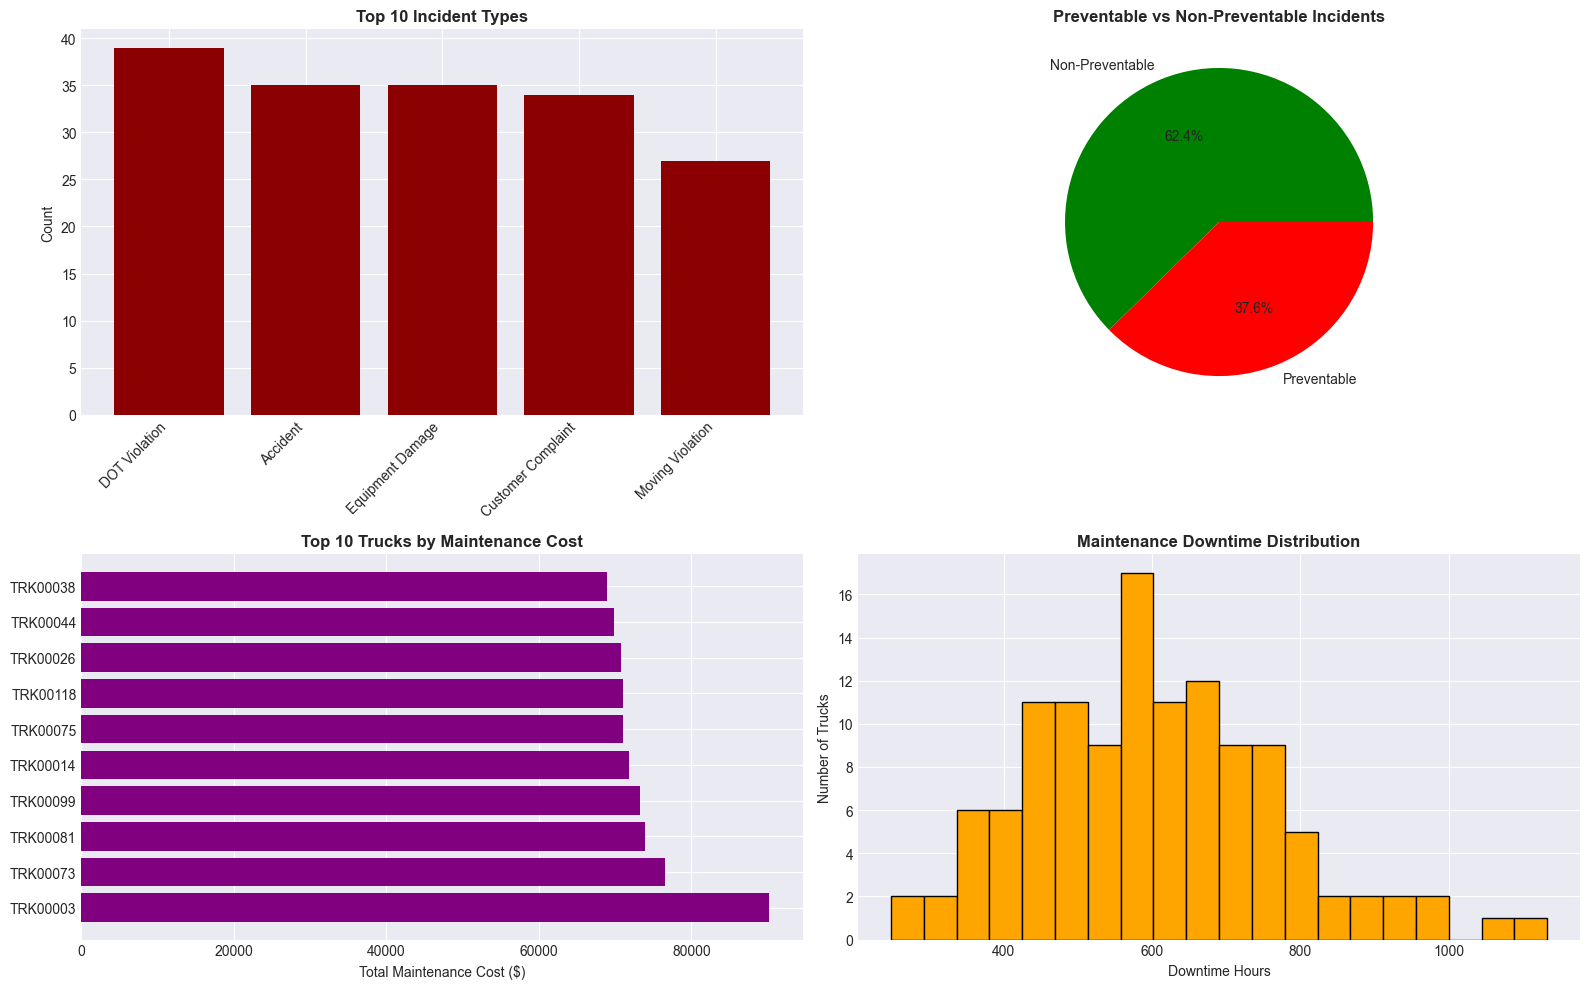

Safety and Maintenance Visualization saved!


In [19]:
# Safety and Maintenance Visualizations
if len(safety_incidents) > 0 and len(maintenance) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Incident types
    incident_types = safety_incidents['incident_type'].value_counts().head(10)
    axes[0, 0].bar(range(len(incident_types)), incident_types.values, color='darkred')
    axes[0, 0].set_xticks(range(len(incident_types)))
    axes[0, 0].set_xticklabels(incident_types.index, rotation=45, ha='right')
    axes[0, 0].set_title('Top 10 Incident Types', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Count')
    
    # Preventable vs Non-preventable (using preventable_flag)
    preventable_counts = safety_incidents['preventable_flag'].value_counts()
    axes[0, 1].pie([preventable_counts.get(False, 0), preventable_counts.get(True, 0)], 
                    labels=['Non-Preventable', 'Preventable'], autopct='%1.1f%%', colors=['green', 'red'])
    axes[0, 1].set_title('Preventable vs Non-Preventable Incidents', fontsize=12, fontweight='bold')
    
    # Maintenance cost by truck
    top_maintenance_cost = maintenance_summary.nlargest(10, 'total_maintenance_cost')
    axes[1, 0].barh(range(len(top_maintenance_cost)), top_maintenance_cost['total_maintenance_cost'], color='purple')
    axes[1, 0].set_yticks(range(len(top_maintenance_cost)))
    axes[1, 0].set_yticklabels(top_maintenance_cost['truck_id'])
    axes[1, 0].set_title('Top 10 Trucks by Maintenance Cost', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Total Maintenance Cost ($)')
    
    # Downtime analysis
    axes[1, 1].hist(maintenance_summary['total_downtime_hours'], bins=20, edgecolor='black', color='orange')
    axes[1, 1].set_title('Maintenance Downtime Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Downtime Hours')
    axes[1, 1].set_ylabel('Number of Trucks')
    
    plt.tight_layout()
    plt.savefig('Safety_Maintenance_Analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Safety and Maintenance Visualization saved!')
else:
    print('Insufficient data for safety and maintenance visualizations')

## 7. EXPORT SUMMARY REPORTS

In [20]:
# Export Key Reports to CSV
driver_performance.to_csv('Driver_Performance_Report.csv', index=False)
fleet_utilization.to_csv('Fleet_Utilization_Report.csv', index=False)
route_profitability.to_csv('Route_Profitability_Report.csv', index=False)
fuel_efficiency.to_csv('Fuel_Efficiency_Report.csv', index=False)

if len(safety_incidents) > 0 and 'driver_incidents' in locals():
    driver_incidents.to_csv('Driver_Safety_Incidents.csv', index=False)
if len(maintenance) > 0 and 'maintenance_summary' in locals():
    maintenance_summary.to_csv('Truck_Maintenance_Report.csv', index=False)

print('All reports exported successfully!')
print('\nFiles created:')
print('- Driver_Performance_Report.csv')
print('- Fleet_Utilization_Report.csv')
print('- Route_Profitability_Report.csv')
print('- Fuel_Efficiency_Report.csv')
if len(safety_incidents) > 0:
    print('- Driver_Safety_Incidents.csv')
if len(maintenance) > 0:
    print('- Truck_Maintenance_Report.csv')

All reports exported successfully!

Files created:
- Driver_Performance_Report.csv
- Fleet_Utilization_Report.csv
- Route_Profitability_Report.csv
- Fuel_Efficiency_Report.csv
- Driver_Safety_Incidents.csv
- Truck_Maintenance_Report.csv


## 8. EXECUTIVE SUMMARY

In [21]:
# Create Executive Summary
print('\n' + '='*80)
print('EXECUTIVE SUMMARY - GLOBETRACK LOGISTICS ANALYTICS'.center(80))
print('='*80 + '\n')

print('FLEET OVERVIEW:')
print(f'  Total Drivers: {len(drivers)}')
print(f'  Active Drivers: {len(drivers[drivers["employment_status"] == "Active"])}')
print(f'  Total Trucks: {len(trucks)}')
print(f'  Active Trucks: {len(trucks[trucks["status"] == "Active"])}')
print(f'  Total Trailers: {len(trailers)}')
print()

print('OPERATIONAL METRICS:')
print(f'  Total Trips: {len(trips)}')
print(f'  Total Miles: {trips["actual_distance_miles"].sum():,.0f}')
print(f'  Total Fuel Used: {trips["fuel_gallons_used"].sum():,.0f} gallons')
print(f'  Fleet Average MPG: {(trips["actual_distance_miles"].sum() / trips["fuel_gallons_used"].sum()):.2f}')
print()

print('FINANCIAL METRICS:')
print(f'  Total Revenue: ${loads["revenue"].sum():,.2f}')
print(f'  Total Fuel Cost: ${trips["fuel_gallons_used"].sum() * 3.5:,.2f}')
print(f'  Revenue per Mile: ${loads["revenue"].sum() / trips["actual_distance_miles"].sum():.2f}')
print()

print('TOP PERFORMERS:')
top_driver = driver_performance.iloc[0]
print(f'  Top Driver: {top_driver["first_name"]} {top_driver["last_name"]} (${top_driver["total_revenue"]:,.2f})')
top_truck = fleet_utilization.iloc[0]
print(f'  Top Truck: {top_truck["truck_id"]} (${top_truck["total_revenue"]:,.2f})')
top_route = route_profitability.iloc[0]
print(f'  Top Route: {top_route["route_id"]} (Profit: ${top_route["profit"]:,.2f})')
print()

if len(delivery_events) > 0 and 'delivery_performance' in locals():
    on_time_rate = (delivery_performance['on_time_flag'].sum() / len(delivery_performance)) * 100
    print(f'  On-Time Delivery Rate: {on_time_rate:.2f}%')
print()

if len(safety_incidents) > 0:
    print(f'  Total Safety Incidents: {len(safety_incidents)}')
    preventable = safety_incidents['preventable_flag'].sum()
    print(f'  Preventable Incidents: {int(preventable)}')
    total_damage = (safety_incidents['vehicle_damage_cost'] + safety_incidents['cargo_damage_cost']).sum()
    print(f'  Total Incident Damage Cost: ${total_damage:,.2f}')
print()

print('KEY INSIGHTS:')
print(f'  1. Average driver revenue per trip: ${(loads["revenue"].sum() / len(trips)):,.2f}')
print(f'  2. Best route profit margin: {route_profitability["profit_margin"].max():.2f}%')
print(f'  3. Worst performing truck MPG: {fuel_efficiency["calculated_mpg"].min():.2f}')
if len(maintenance) > 0:
    print(f'  4. Total maintenance cost: ${maintenance["total_cost"].sum():,.2f}')
print()

print('='*80)
print('END OF REPORT'.center(80))
print('='*80)


               EXECUTIVE SUMMARY - GLOBETRACK LOGISTICS ANALYTICS               

FLEET OVERVIEW:
  Total Drivers: 150
  Active Drivers: 124
  Total Trucks: 120
  Active Trucks: 92
  Total Trailers: 180

OPERATIONAL METRICS:
  Total Trips: 85410
  Total Miles: 122,159,201
  Total Fuel Used: 18,946,280 gallons
  Fleet Average MPG: 6.45

FINANCIAL METRICS:
  Total Revenue: $262,525,800.29
  Total Fuel Cost: $66,311,980.35
  Revenue per Mile: $2.15

TOP PERFORMERS:
  Top Driver: Linda Davis ($2,311,844.30)
  Top Truck: TRK00044 ($3,045,707.57)
  Top Route: RTE00044 (Profit: $7,282,041.00)

  On-Time Delivery Rate: 55.67%

  Total Safety Incidents: 170
  Preventable Incidents: 64
  Total Incident Damage Cost: $2,653,171.82

KEY INSIGHTS:
  1. Average driver revenue per trip: $3,073.71
  2. Best route profit margin: 74.01%
  3. Worst performing truck MPG: 6.39
  4. Total maintenance cost: $5,730,573.28

                                 END OF REPORT                                  
